# Setup


In [1]:
# Optional autoreload while developing locally

%load_ext autoreload
%autoreload 2


In [2]:
# to load the virtual environment
## & "$HOME\nlp_owlapy_env_py311\Scripts\Activate.ps1"


In [3]:

# 0) Local-only setup and base diagnostics
import os
import sys
import platform
from pathlib import Path

print("Python:", sys.version)
print("Platform:", platform.platform())

PROJECT_DIR = Path.cwd()


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0


In [4]:

# 0.3) Shared device diagnostics
import torch

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    print("GPU 0:", torch.cuda.get_device_name(0))
    DEVICE = "cuda:0"
else:
    DEVICE = "cpu"
print("Using DEVICE =", DEVICE)


torch: 2.11.0+cu128
CUDA available: True
GPU count: 1
GPU 0: NVIDIA RTX A2000 8GB Laptop GPU
Using DEVICE = cuda:0


# Imports


In [5]:
import pickle
import re

import pandas as pd
from spacy.tokens import Doc

from dataclasses import dataclass, asdict
from itertools import product

from tokenizer import create_tokenizer, ensure_booknlp_extensions, tokens_to_dicts
from doc_chunker import create_chunker
from runtime_config import (
    RUNTIME_PROFILE,
    DEVICE,
    CHUNK_SIZE,
    OVERLAP_SENTENCES,
    MAX_EXPANDED_CHUNK_TOKENS,
)


In [6]:
from entity_extraction.entity_extraction_sub_orchestrator import (
    run_entity_extraction,
    print_non_singleton_entity_clusters,
)

from annotation_layer.spacy_extension import (
    register_spacy_annotation_extension,
    require_annotation_layer,
    require_entities,
    require_relations,
)


In [7]:
from ocean.ocean_probability_scoring import (
    OceanContextConfig,
    OceanMentionRenderingConfig,
    OceanScoringConfig,
    OceanWeightConfig,
    OceanDirectNLIConfig,
    OceanProbabilityExportConfig,
    export_ocean_probability_csvs,
)

from ocean.ocean_annotator import attach_ocean_from_folder
from ocean.ontology_selection import entity_cluster_ids_with_ocean_data_fields
from ontology.data_properties import add_ocean_data_fields_to_class
from cluster_typing.graph_contract import resolve_class_label


In [8]:
from cluster_typing.cluster_typing_probability_scoring import (
    ClusterTypingContextConfig,
    ClusterTypingMentionRenderingConfig,
    ClusterTypingDirectNLIConfig,
    ClusterTypingTraversalConfig,
    ClusterTypingScoringConfig,
    ClusterTypingMentionWeightConfig,
    ClusterTypingEvidenceExportConfig,
    export_cluster_typing_evidence_jsonls,
)

from cluster_typing.cluster_typing_annotator import (
    ClusterTypingAnnotationConfig,
    attach_cluster_typing_from_folder,
)

from cluster_typing.graph_contract import (
    class_human_readable_label,
    class_label,
    ontology_descendants,
    resolve_class_label,
)


In [9]:
from ontology.ontology_management import (
    NarrativeOntology,
    local_name,
)


In [10]:
from relationship_extraction.extract_relation_candidates import (
    extract_relation_candidates,
    export_routed_relation_candidates_jsonl,
)

from relationship_extraction.align_relation_assignments import (
    RelationAssignmentExportConfig,
    RelationDirectNLIConfig,
    RelationScoringConfig,
    export_relation_assignments_csv,
)

from relationship_extraction.aggregate_cluster_assertions import (
    RelationAggregationConfig,
    export_cluster_assertions_csv,
)

from relationship_extraction.annotate_relation_layer import (
    attach_relations_from_files,
)


# Functions


In [11]:
# text loading + preprocessing
def load_txt(path):
    path = Path(path)

    try:
        return path.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        return path.read_text(encoding="latin-1")


In [12]:
import re

def preprocess_for_NER(text):
    # Normalize Windows/Mac newlines
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # Remove possible invisible BOM
    text = text.replace("\ufeff", "")

    # Normalize curly apostrophes/quotes
    text = text.replace("’", "'")
    text = text.replace("‘", "'")
    text = text.replace("“", '"').replace("”", '"')

    # Remove standalone page numbers, e.g.
    # This removes only lines that contain digits plus optional whitespace.
    text = re.sub(r"(?m)^[ \t]*\d+[ \t]*$", "", text)

    # Replace line breaks inside paragraphs with spaces,
    # but preserve paragraph boundaries
    paragraphs = text.split("\n\n")
    paragraphs = [
        re.sub(r"\s*\n\s*", " ", paragraph).strip()
        for paragraph in paragraphs
        if paragraph.strip()
    ]

    text = "\n\n".join(paragraphs)

    chapter_re = re.compile(
        r"(?im)^\s*chapter\s+(?:[ivxlcdm]+|\d+)\b[^\n]*\n*"
    )

    text = chapter_re.sub("", text)

    # Normalize multiple spaces
    text = re.sub(r"[ \t]+", " ", text)

    return text.strip()


In [13]:

def resolve_text_path(
    *,
    project_dir: Path,
    filename: str,
    local_path: str | Path,
) -> Path:
    """Resolve the local input text path."""
    text_path = Path(local_path)
    if text_path.exists():
        return text_path

    fallback_path = project_dir / filename
    if fallback_path.exists():
        return fallback_path

    raise FileNotFoundError(
        "Could not resolve a local text file. "
        f"Tried LOCAL_TEXT_PATH={text_path} and PROJECT_DIR / {filename!r} = {fallback_path}."
    )


In [14]:
def save_doc(doc, path: str | Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as f:
        pickle.dump(doc, f)
    return path


def load_doc(path: str | Path):
    # BookNLP/tokenizer extensions and the unified annotation_layer extension
    # must be registered before unpickling the Doc.
    ensure_booknlp_extensions()
    register_spacy_annotation_extension()
    
    path = Path(path)
    with path.open("rb") as f:
        return pickle.load(f)


# Config


## I/O config


In [15]:
# Requested local file
BOOK_NAME = "cosmicomics_a_sign_in_space"
TEXT_FILENAME = f"{BOOK_NAME}.txt"
LOCAL_TEXT_PATH = Path(f"./resources/books/{TEXT_FILENAME}")

TEXT_PATH = resolve_text_path(
    project_dir=PROJECT_DIR,
    filename=TEXT_FILENAME,
    local_path=LOCAL_TEXT_PATH,
)

OUTPUT_ROOT = PROJECT_DIR / "outputs" / f"outputs_[{BOOK_NAME}]"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
ONTOLOGY_ROOT = PROJECT_DIR / "resources/ontologies"

TOKENIZED_DOC_PATH = OUTPUT_ROOT / "tokenized_doc.pkl"
ENTITY_ANNOTATED_DOC_PATH = OUTPUT_ROOT / "entity_annotated_doc.pkl"
TYPED_ENTITY_DOC_PATH = OUTPUT_ROOT / "typed_entity_doc.pkl"
OCEAN_ENTITY_DOC_PATH = OUTPUT_ROOT / "ocean_entity_doc.pkl"
RELATION_ANNOTATED_DOC_PATH = OUTPUT_ROOT / "relation_annotated_doc.pkl"

ONTOLOGY_NAME = "balanced_ontology"
ONTOLOGY_TTL_PATH = ONTOLOGY_ROOT / f"{ONTOLOGY_NAME}.ttl"
ONTOLOGY_EXTENSION = ONTOLOGY_TTL_PATH.suffix.lstrip(".")
POPULATED_ONTOLOGY_PATH = (
    OUTPUT_ROOT / f"{ONTOLOGY_NAME}_populated_{BOOK_NAME}.{ONTOLOGY_EXTENSION}"
)
ABOX_BASE_IRI = f"https://example.org/nlp-character-graph/{BOOK_NAME}#"

RELATION_OUTPUT_DIR = OUTPUT_ROOT / "relations"
RELATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ROUTED_RELATION_CANDIDATES_PATH = RELATION_OUTPUT_DIR / "routed_relation_candidates.jsonl"
RELATION_ASSIGNMENTS_PATH = RELATION_OUTPUT_DIR / "relation_assignments.csv"
CLUSTER_ASSERTIONS_PATH = RELATION_OUTPUT_DIR / "cluster_assertions.csv"

print("TEXT_PATH =", TEXT_PATH)
print("OUTPUT_ROOT =", OUTPUT_ROOT)
print("TOKENIZED_DOC_PATH =", TOKENIZED_DOC_PATH)
print("ENTITY_ANNOTATED_DOC_PATH =", ENTITY_ANNOTATED_DOC_PATH)
print("TYPED_ENTITY_DOC_PATH =", TYPED_ENTITY_DOC_PATH)
print("OCEAN_ENTITY_DOC_PATH =", OCEAN_ENTITY_DOC_PATH)
print("RELATION_ANNOTATED_DOC_PATH =", RELATION_ANNOTATED_DOC_PATH)
print("ONTOLOGY_TTL_PATH =", ONTOLOGY_TTL_PATH)
print("POPULATED_ONTOLOGY_PATH =", POPULATED_ONTOLOGY_PATH)
print("ABOX_BASE_IRI =", ABOX_BASE_IRI)


TEXT_PATH = resources\books\cosmicomics_a_sign_in_space.txt
OUTPUT_ROOT = c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]
TOKENIZED_DOC_PATH = c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\tokenized_doc.pkl
ENTITY_ANNOTATED_DOC_PATH = c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\entity_annotated_doc.pkl
TYPED_ENTITY_DOC_PATH = c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\typed_entity_doc.pkl
OCEAN_ENTITY_DOC_PATH = c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\ocean_entity_doc.pkl
RELATION_ANNOTATED_DOC_PATH = c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\relation_annotated_doc.pkl
ONTOLOGY_TTL_PATH = c:\Users\Bobby\Desk

In [16]:
GLOBAL_ENTITY_OUTPUT_DIR = OUTPUT_ROOT / "global_entities"
GLOBAL_ENTITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("GLOBAL_ENTITY_OUTPUT_DIR =", GLOBAL_ENTITY_OUTPUT_DIR)


GLOBAL_ENTITY_OUTPUT_DIR = c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\global_entities


## Runtime and pipeline config


In [17]:
# Pipeline configuration
SPACY_MODEL = "en_core_web_sm"
TOKENIZER_DISABLE = ("ner",)

OCEAN_FIELD_OWNER_CLASS_LABEL = "Character"

RELATION_PAIR_BATCH_SIZE = 64
RELATION_OVERWRITE_STAGE_1 = False
RELATION_OVERWRITE_STAGE_2 = False
RELATION_RESUME_STAGE_2 = True
RELATION_OVERWRITE_STAGE_3 = True

print("RUNTIME_PROFILE =", RUNTIME_PROFILE)
print("DEVICE =", DEVICE)
print("CHUNK_SIZE(expanded) =", CHUNK_SIZE)
print("OVERLAP_SENTENCES =", OVERLAP_SENTENCES)
print("MAX_EXPANDED_CHUNK_TOKENS =", MAX_EXPANDED_CHUNK_TOKENS)
print("GLOBAL_ENTITY_OUTPUT_DIR =", GLOBAL_ENTITY_OUTPUT_DIR)


RUNTIME_PROFILE = {'kind': 'local_cuda', 'env': 'Local', 'cuda_available': True, 'gpu_count': 1, 'gpu_name': 'NVIDIA RTX A2000 8GB Laptop GPU', 'device': 'cuda:0', 'cpu_load_first': True, 'precision_policy': 'auto', 'p100_fallback_to_float32': False, 'default_chunk_size': 6000, 'default_overlap_sentences': 60}
DEVICE = cuda:0
CHUNK_SIZE(expanded) = 6000
OVERLAP_SENTENCES = 60
MAX_EXPANDED_CHUNK_TOKENS = 6000
GLOBAL_ENTITY_OUTPUT_DIR = c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\global_entities


# Main


## Tokenization


In [18]:
# Load or create the stable tokenized Doc artifact.
if TOKENIZED_DOC_PATH.exists():
    print(f"[doc] Loading tokenized Doc from {TOKENIZED_DOC_PATH}")
    doc = load_doc(TOKENIZED_DOC_PATH)
else:
    print("[doc] Tokenized Doc not found; creating it from raw text.")
    raw_text = load_txt(TEXT_PATH)
    text = preprocess_for_NER(raw_text)
    tokenizer = create_tokenizer(
        SPACY_MODEL,
        disable=TOKENIZER_DISABLE,
        verbose=True,
    )
    doc = tokenizer.tokenize(text)
    save_doc(doc, TOKENIZED_DOC_PATH)
    print(f"[doc] Saved tokenized Doc to {TOKENIZED_DOC_PATH}")

print("Doc tokens:", len(doc))
print("Doc sentences:", sum(1 for _ in doc.sents))


[doc] Tokenized Doc not found; creating it from raw text.
[tokenizer:init] TextTokenizer ready: pipeline=['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer'], disabled=['senter', 'ner'], max_length=10000000
[tokenizer:tokenize] Starting raw-text tokenization: characters=19049, approx_words=3498
[tokenizer:spacy] make_doc started
[tokenizer:spacy] make_doc finished: seconds=0.02, tokens=4092
[tokenizer:spacy] component 'tok2vec' started
[tokenizer:spacy] component 'tok2vec' finished: seconds=0.11
[tokenizer:spacy] component 'tagger' started
[tokenizer:spacy] component 'tagger' finished: seconds=0.00
[tokenizer:spacy] component 'parser' started
[tokenizer:spacy] component 'parser' finished: seconds=0.16
[tokenizer:spacy] component 'attribute_ruler' started
[tokenizer:spacy] component 'attribute_ruler' finished: seconds=0.09
[tokenizer:spacy] component 'lemmatizer' started
[tokenizer:spacy] component 'lemmatizer' finished: seconds=0.06
[tokenizer:tokenize] spaCy processing fin

## Chunking


In [19]:
chunker = create_chunker(
    chunk_size=CHUNK_SIZE,
    overlap_sentences=OVERLAP_SENTENCES,
    max_expanded_chunk_tokens=MAX_EXPANDED_CHUNK_TOKENS,
)
chunk_plan = chunker.plan(doc)


## Ontology building


In [20]:
narrative_ontology = NarrativeOntology(
    ONTOLOGY_TTL_PATH,
    require_property_descriptions=True,
)

class_graph = narrative_ontology.to_networkx_class_graph(
    ontology_path=ONTOLOGY_TTL_PATH,
)

print(class_graph.number_of_nodes(), "classes")
print(class_graph.number_of_edges(), "subclass edges")

relation_router = narrative_ontology.build_relation_router(
    ontology_path=ONTOLOGY_TTL_PATH,
    class_graph=class_graph,
)


# Add the OCEAN datatype-field contract to the selected ontology class,
# then rebuild the derived class graph so inherited field metadata is visible.
ocean_field_owner_class_iri = resolve_class_label(
    class_graph,
    OCEAN_FIELD_OWNER_CLASS_LABEL,
)

add_ocean_data_fields_to_class(
    narrative_ontology.onto,
    class_iri=ocean_field_owner_class_iri,
)


class_graph = narrative_ontology.to_networkx_class_graph(
    ontology_path=ONTOLOGY_TTL_PATH,
)


print("Object properties:", len(relation_router.relation_specs))




21 classes
20 subclass edges
Object properties: 21


In [21]:
# Add the OCEAN datatype-field contract to the selected ontology class,
# then rebuild the derived class graph so inherited field metadata is visible.
ocean_field_owner_class_iri = resolve_class_label(
    class_graph,
    OCEAN_FIELD_OWNER_CLASS_LABEL,
)

add_ocean_data_fields_to_class(
    narrative_ontology.onto,
    class_iri=ocean_field_owner_class_iri,
)

class_graph = narrative_ontology.to_networkx_class_graph(
    ontology_path=ONTOLOGY_TTL_PATH,
)

## Node extraction


### Entity clusters extraction


In [22]:
if ENTITY_ANNOTATED_DOC_PATH.exists():
    print(f"[entity-extraction] Loading entity-annotated Doc from {ENTITY_ANNOTATED_DOC_PATH}")
    doc = load_doc(ENTITY_ANNOTATED_DOC_PATH)
else:
    print("[entity-extraction] Entity-annotated Doc not found; calling entity extraction sub-orchestrator.")
    doc = run_entity_extraction(
        doc=doc,
        chunker=chunker,
        chunk_plan=chunk_plan,
        document_id=TEXT_PATH.stem,
        output_dir=GLOBAL_ENTITY_OUTPUT_DIR,
    )
    save_doc(doc, ENTITY_ANNOTATED_DOC_PATH)
    print("[entity-extraction] Saved annotated Doc to:", ENTITY_ANNOTATED_DOC_PATH)


[entity-extraction] Entity-annotated Doc not found; calling entity extraction sub-orchestrator.
torch.load safely patched: True
[coref] Extractor build: streaming-safe device='cuda:0', precision_policy='auto', cpu_load_first=True.
[chunk] Processing chunk_000 (1/1) expanded_tokens=4092
[coref] Prepared Maverick input: 98 sentences, 4064 tokens.
[coref][runtime] torch=2.11.0+cu128
[coref][runtime] torch_cuda=12.8
[coref][runtime] cuda_available=True
[coref][runtime] gpu='NVIDIA RTX A2000 8GB Laptop GPU'
[coref][runtime] capability=(8, 6)
[coref][runtime] compiled_arches=['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


c:\Users\Bobby\nlp_owlapy_env_py311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[coref] Patched Transformers resize_token_embeddings(mean_resizing=False).


W0630 10:37:23.354000 31364 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[coref] Loading Maverick model 'sapienzanlp/maverick-mes-litbank'. load_device='cpu', requested_device='cuda:0'.
[coref][memory] before Maverick(...): cuda_allocated=0.0 MiB, cuda_reserved=0.0 MiB
sapienzanlp/maverick-mes-litbank loading


Loading weights: 100%|██████████| 390/390 [00:00<00:00, 55393.79it/s]
[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not 

[coref][memory] after Maverick(...) on load_device: cuda_allocated=0.0 MiB, cuda_reserved=0.0 MiB
[coref] Maverick model normalized for inference: policy=cuda-float16, parameter_dtypes=['torch.float16'], floating_buffer_dtypes=[], parameter_devices=['cuda:0'].
[coref][memory] after dtype/device normalization: cuda_allocated=962.0 MiB, cuda_reserved=966.0 MiB
[coref] Alignment check OK: Maverick tokens match spaCy tokens.
[coref][drop] too-long mention (29 tokens): 'a spiteful type, consumed with envy, who had erased my sign in a vandalistic impulse and then, with vulgar artifice, had attempted to make another'
[coref] chunk_000: dropped 1 suspicious/pathological mentions.
[coref] chunk_000: extracted 76 local clusters, 368 local mentions.
[chunk] chunk_000: clusters=76, mentions=368
Saved final artifact to c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\maverick_local_clusters.zip
Artifact metadata:
{'artifact_type': 'local_cl

In [23]:
ann = require_annotation_layer(doc)
entities = ann.require_entities()
print_non_singleton_entity_clusters(doc)
print(ann.summary())


Non-singleton clusters: 10

cluster_id=2 | canonical_name='I' | n_mentions=210

cluster_id=0 | canonical_name='the endless fields of space' | n_mentions=20

cluster_id=9 | canonical_name='Kgwgk' | n_mentions=20

cluster_id=1 | canonical_name='the Galaxy' | n_mentions=19

cluster_id=3 | canonical_name='we' | n_mentions=14

cluster_id=4 | canonical_name='you' | n_mentions=13

cluster_id=7 | canonical_name='our world' | n_mentions=8

cluster_id=8 | canonical_name='the only one who had ever made signs' | n_mentions=6

cluster_id=6 | canonical_name='billions of planets of other solar systems' | n_mentions=5

cluster_id=5 | canonical_name='the universe' | n_mentions=4

{'has_entities': True, 'has_cluster_typing': False, 'has_ocean': False, 'has_relations': False, 'n_mentions': 319, 'n_clusters': 10, 'n_typed_clusters': 0, 'n_ocean_clusters': 0, 'n_indexed_tokens': 390, 'n_indexed_heads': 319, 'n_indexed_spans': 319}


### Ontology cluster typing


In [24]:
ontology_n_mentions = None  # None = type ALL mentions for each requested cluster
ontology_random_seed = 67


In [25]:
if TYPED_ENTITY_DOC_PATH.exists():
    print(f"[entity typing] Loading typed-entity Doc from {TYPED_ENTITY_DOC_PATH}")
    doc = load_doc(TYPED_ENTITY_DOC_PATH)
else:
    if not ONTOLOGY_TTL_PATH.exists():
        raise FileNotFoundError(
            f"Ontology TTL not found: {ONTOLOGY_TTL_PATH}. "
            "Create a networkx.DiGraph by any external method, or place the TTL here."
        )

    jsonl_paths_by_cluster_id = export_cluster_typing_evidence_jsonls(
        doc,
        class_graph,
        ClusterTypingEvidenceExportConfig(
            n_mentions_per_cluster=ontology_n_mentions,
            output_root=OUTPUT_ROOT,

            context_config=ClusterTypingContextConfig(
                n_sentences_before=0,
                n_sentences_after=0,
                mark_mention=True,
                deduplicate=False,
            ),
            rendering_config=ClusterTypingMentionRenderingConfig(
                canonicalize_simple_mentions=True,
                keep_first_second_person=True,
            ),
            traversal_config=ClusterTypingTraversalConfig(
                skip_single_root=True,
                include_stay_option=True,
                force_leaf=False,
            ),
            scoring_config=ClusterTypingScoringConfig(
                subject_aware=True,
            ),
            mention_weight_config=ClusterTypingMentionWeightConfig(),
            nli_config=ClusterTypingDirectNLIConfig(
                pair_batch_size=64,
            ),

            chunk_size=32,

            overwrite_jsonl=True,
            resume_from_jsonl=True,

            random_seed=ontology_random_seed,
            sort_sample_by_cluster_order=True,
            print_progress=True,
        ),
    )

    print(jsonl_paths_by_cluster_id)

    n_part = "all" if ontology_n_mentions is None else str(ontology_n_mentions)
    ontology_folder = OUTPUT_ROOT / "cluster_typing" / n_part

    attach_cluster_typing_from_folder(
        doc,
        class_graph,
        ontology_folder,
        config=ClusterTypingAnnotationConfig(
            use_mention_weight=True,
        ),
        overwrite=True,
    )
    save_doc(doc, TYPED_ENTITY_DOC_PATH)
    print("[entity typing] Saved annotated Doc to:", TYPED_ENTITY_DOC_PATH)

ann = require_annotation_layer(doc)
entities = ann.require_entities()
print(ann.summary())


All-cluster cluster-typing evidence export
cluster source: doc._.annotation_layer.entities.clusters
n_clusters: 10
cluster_ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n_mentions_per_cluster: None
output_dir: c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\cluster_typing\all

----------------------------------------------------------------------------------------------------
cluster 1/10
cluster_id: 0
subject: 'the endless fields of space'
jsonl_path: c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\cluster_typing\all\cluster_typing_evidence_cluster_0_the_endless_fields_of_space_all.jsonl
per_cluster_seed: 12622576784306766662
----------------------------------------------------------------------------------------------------
Cluster-typing evidence JSONL export
cluster_id: 0
subject: 'the endless fields of space'
requested mentions: None
total mentions in cluster: 20
jsonl_pat

Loading weights: 100%|██████████| 394/394 [00:00<00:00, 4141.66it/s]


[chunk 1/1] mentions=0:20 | chunk_time=16.96s | done_total=20/20
ONTOLOGY EVIDENCE JSONL EXPORT COMPLETE
new records written: 20
skipped from existing JSONL: 0
elapsed scoring/export time: 17.12s
jsonl saved to: c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\cluster_typing\all\cluster_typing_evidence_cluster_0_the_endless_fields_of_space_all.jsonl

----------------------------------------------------------------------------------------------------
cluster 2/10
cluster_id: 1
subject: 'the Galaxy'
jsonl_path: c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\cluster_typing\all\cluster_typing_evidence_cluster_1_the_Galaxy_all.jsonl
per_cluster_seed: 8825220446749074408
----------------------------------------------------------------------------------------------------
Cluster-typing evidence JSONL export
cluster_id: 1
subject: 'the Galaxy'
requested mentions: None
total m

In [26]:
ann = require_annotation_layer(doc)
entities = ann.require_entities()

rows = []

for cluster_id, cluster in sorted(entities.clusters.items()):
    typing = cluster.typing
    class_iri = typing.class_iri if typing is not None else None
    rows.append(
        {
            "cluster_id": cluster_id,
            "canonical_name": cluster.canonical_name,
            "n_mentions": len(cluster.mention_ids),
            "class_iri": class_iri,
            "ontology_class_label": class_label(class_graph, class_iri) if class_iri else None,
            "ontology_class_human_readable_label": class_human_readable_label(class_graph, class_iri) if class_iri else None,
        }
    )

ontology_clusters_df = pd.DataFrame(rows)

ontology_clusters_df


,cluster_id,canonical_name,n_mentions,class_iri,ontology_class_label,ontology_class_human_readable_label
0,0,the endless fields of space,20,https://example.org/narrative-character-ontolo...,Artifact,Artifact
1,1,the Galaxy,19,https://example.org/narrative-character-ontolo...,Substance,Substance
2,2,I,210,https://example.org/narrative-character-ontolo...,Character,Character
3,3,we,14,https://example.org/narrative-character-ontolo...,Artifact,Artifact
4,4,you,13,https://example.org/narrative-character-ontolo...,Character,Character
5,5,the universe,4,https://example.org/narrative-character-ontolo...,Artifact,Artifact
6,6,billions of planets of other solar systems,5,https://example.org/narrative-character-ontolo...,Substance,Substance
7,7,our world,8,https://example.org/narrative-character-ontolo...,Site,Site
8,8,the only one who had ever made signs,6,https://example.org/narrative-character-ontolo...,AgentiveEntity,Agentive Entity
9,9,Kgwgk,20,https://example.org/narrative-character-ontolo...,Character,Character


### OCEAN scoring


In [27]:
ann = require_annotation_layer(doc)
entities = ann.require_entities()

cluster_ids = entity_cluster_ids_with_ocean_data_fields(
    entities,
    class_graph,
    field_owner_class_iri=ocean_field_owner_class_iri,
)


In [28]:
n_mentions = None  # None = score ALL mentions for each requested cluster
random_seed = 67

In [29]:
if OCEAN_ENTITY_DOC_PATH.exists():
    print(f"[OCEAN scoring] Loading OCEAN-entity Doc from {OCEAN_ENTITY_DOC_PATH}")
    doc = load_doc(OCEAN_ENTITY_DOC_PATH)
else:
    csv_paths_by_cluster_id = export_ocean_probability_csvs(
        doc,
        OceanProbabilityExportConfig(
            cluster_ids=cluster_ids,
            n_mentions_per_cluster=n_mentions,
            output_root=OUTPUT_ROOT,

            context_config=OceanContextConfig(
                n_sentences_before=0,
                n_sentences_after=0,
                mark_mention=True,
                deduplicate=False,
            ),
            rendering_config=OceanMentionRenderingConfig(
                canonicalize_simple_mentions=True,
                keep_first_second_person=True,
            ),
            scoring_config=OceanScoringConfig(
                subject_aware=True,
            ),
            weight_config=OceanWeightConfig(),
            nli_config=OceanDirectNLIConfig(
                pair_batch_size=64, # on stronger hardware can be safely set to 64
            ),

            chunk_size=64,

            overwrite_csv=False,
            resume_from_csv=True,
            use_sqlite_cache=True,

            random_seed=random_seed,
            sort_sample_by_cluster_order=True,
            return_dataframes=False,
            print_progress=True,
        ),
    )

    print(csv_paths_by_cluster_id)

    n_part = "all" if n_mentions is None else str(n_mentions)
    ocean_folder = OUTPUT_ROOT / "OCEAN_profiles" / n_part

    attach_ocean_from_folder(
        doc,
        ocean_folder,
        overwrite=True,
    )
    save_doc(doc, OCEAN_ENTITY_DOC_PATH)
    print("[OCEAN scoring] Saved annotated Doc to:", OCEAN_ENTITY_DOC_PATH)

ann = require_annotation_layer(doc)
print(ann.summary())


Multi-cluster OCEAN probability export
cluster_ids: [2, 4, 9]
n_mentions_per_cluster: None
output_dir: c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\OCEAN_profiles\all

----------------------------------------------------------------------------------------------------
cluster 1/3
cluster_id: 2
subject: 'I'
csv_path: c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\OCEAN_profiles\all\OCEAN_scores_cluster_2_I_all.csv
per_cluster_seed: 6916691663206971582
----------------------------------------------------------------------------------------------------
OCEAN probability CSV export
cluster_id: 2
subject: 'I'
requested mentions: None
total mentions in cluster: 210
csv_path: c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\OCEAN_profiles\all\OCEAN_scores_cluster_2_I_all.csv
cache_path: c:\Users\Bobby\Desktop\rea

In [30]:
ann = require_annotation_layer(doc)
entities = ann.require_entities()

for cluster_id in cluster_ids:
    cluster = entities.cluster(cluster_id)
    print(cluster.canonical_name, sep="->")
    print(cluster.ocean.scores.as_dict() if cluster.ocean is not None else None)


I
{'openness': 46.12, 'conscientiousness': 31.17, 'extraversion': 37.83, 'agreeableness': 44.79, 'neuroticism': 57.17}
you
{'openness': 53.14, 'conscientiousness': 50.11, 'extraversion': 39.8, 'agreeableness': 51.36, 'neuroticism': 14.18}
Kgwgk
{'openness': 50.59, 'conscientiousness': 54.14, 'extraversion': 49.38, 'agreeableness': 19.16, 'neuroticism': 41.16}


## Edge extraction


In [31]:
for relation_iri in sorted(relation_router.relation_specs):
    print(relation_iri)


https://example.org/narrative-character-ontology#caresFor
https://example.org/narrative-character-ontology#corrupts
https://example.org/narrative-character-ontology#createsObject
https://example.org/narrative-character-ontology#curses
https://example.org/narrative-character-ontology#deceives
https://example.org/narrative-character-ontology#destroysObject
https://example.org/narrative-character-ontology#empowers
https://example.org/narrative-character-ontology#fears
https://example.org/narrative-character-ontology#follows
https://example.org/narrative-character-ontology#guides
https://example.org/narrative-character-ontology#heals
https://example.org/narrative-character-ontology#leavesPlace
https://example.org/narrative-character-ontology#locatedIn
https://example.org/narrative-character-ontology#occursAt
https://example.org/narrative-character-ontology#opposes
https://example.org/narrative-character-ontology#participatesIn
https://example.org/narrative-character-ontology#possessesObjec

In [32]:
def print_tree(g, root=None, indent=""):
    def label(n):
        data = g.nodes[n]
        return data.get("human_readable_label") or data.get("label") or str(n).split("#")[-1]

    if root is None:
        roots = [n for n in g.nodes if g.in_degree(n) == 0]
        for r in roots:
            print_tree(g, r)
        return

    print(indent + label(root))

    children = sorted(g.successors(root), key=label)
    for child in children:
        print_tree(g, child, indent + "    ")

print_tree(class_graph)


Narrative Entity
    Agentive Entity
        Character
        Group
            Informal Group
            Organization
    Event
        Conflict Event
        Journey Event
        Ritual Event
    Object
        Artifact
        Substance
        Tool
        Vehicle
        Weapon
    Place
        Region
        Route Or Path
        Settlement
        Site


In [33]:
# Inspect relation_router

import pandas as pd

def short(iri):
    iri = str(iri)
    return iri.rsplit("#", 1)[-1] if "#" in iri else iri.rstrip("/").rsplit("/", 1)[-1]

relation_specs = relation_router.relation_specs

router_df = pd.DataFrame([
    {
        "property": short(spec.iri),
        "domains": ", ".join(short(x) for x in spec.domains),
        "ranges": ", ".join(short(x) for x in spec.ranges),
        "label": spec.human_readable_label,
        "description": spec.description,
    }
    for spec in relation_specs.values()
])

print(f"Object properties in router: {len(router_df)}")
display(router_df.sort_values("property"))


Object properties in router: 21


,property,domains,ranges,label,description
20,caresFor,"Thing, AgentiveEntity, NarrativeEntity","Thing, AgentiveEntity, NarrativeEntity",Cares For,connects an acting participant to another acti...
19,corrupts,"Thing, NarrativeEntity, Object","Thing, AgentiveEntity, NarrativeEntity",Corrupts,connects an object to an acting participant wh...
18,createsObject,"Thing, AgentiveEntity, NarrativeEntity","Thing, NarrativeEntity, Object",Creates Object,connects an acting participant to an object it...
17,curses,"Thing, NarrativeEntity, Object","Thing, AgentiveEntity, NarrativeEntity",Curses,connects an object to an acting participant wh...
16,deceives,"Thing, AgentiveEntity, NarrativeEntity","Thing, AgentiveEntity, NarrativeEntity",Deceives,connects an acting participant to another acti...
15,destroysObject,"Thing, AgentiveEntity, NarrativeEntity","Thing, NarrativeEntity, Object",Destroys Object,connects an acting participant to an object it...
14,empowers,"Thing, NarrativeEntity, Object","Thing, AgentiveEntity, NarrativeEntity",Empowers,connects an object to an acting participant wh...
13,fears,"Thing, AgentiveEntity, NarrativeEntity","Thing, AgentiveEntity, NarrativeEntity",Fears,connects an acting participant to another acti...
12,follows,"Thing, AgentiveEntity, NarrativeEntity","Thing, AgentiveEntity, NarrativeEntity",Follows,connects an acting participant to another acti...
11,guides,"Thing, AgentiveEntity, NarrativeEntity","Thing, AgentiveEntity, NarrativeEntity",Guides,connects an acting participant to another acti...


In [34]:
relation_candidates_df = extract_relation_candidates(doc)

relation_candidates_df[
    [
        "source_cluster_id",
        "source_canonical_name",
        "source_class_iri",
        "predicate",
        "target_cluster_id",
        "target_canonical_name",
        "target_class_iri",
        "sentence_text",
        "is_passive",
        "is_negated",
    ]
]

export_routed_relation_candidates_jsonl(
    doc=doc,
    relation_router=relation_router,
    output_path=ROUTED_RELATION_CANDIDATES_PATH,
    print_discards=True,
    overwrite=True,
)


[the Galaxy (type: Substance)][run_through][the endless fields of space (type: Artifact)] because [no relationship between Substance and Artifact]
[relation extraction] Wrote 9 routed candidates to c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\relations\routed_relation_candidates.jsonl


WindowsPath('c:/Users/Bobby/Desktop/real_shit/NLP_character_graph_pipeline/outputs/outputs_[cosmicomics_a_sign_in_space]/relations/routed_relation_candidates.jsonl')

In [35]:
export_relation_assignments_csv(
    input_path=ROUTED_RELATION_CANDIDATES_PATH,
    output_path=RELATION_ASSIGNMENTS_PATH,
    config=RelationAssignmentExportConfig(
        scoring_config=RelationScoringConfig(),
        nli_config=RelationDirectNLIConfig(
            pair_batch_size=RELATION_PAIR_BATCH_SIZE,
        ),
        overwrite_csv=RELATION_OVERWRITE_STAGE_2,
        resume_from_csv=RELATION_RESUME_STAGE_2,
        print_progress=True,
    ),
)


[relation alignment] Wrote 9 assignments to c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\relations\relation_assignments.csv (0 skipped by resume).


WindowsPath('c:/Users/Bobby/Desktop/real_shit/NLP_character_graph_pipeline/outputs/outputs_[cosmicomics_a_sign_in_space]/relations/relation_assignments.csv')

In [36]:
export_cluster_assertions_csv(
    assignments_path=RELATION_ASSIGNMENTS_PATH,
    output_path=CLUSTER_ASSERTIONS_PATH,
    aggregation_config=RelationAggregationConfig(),
    overwrite=RELATION_OVERWRITE_STAGE_3,
)


[relation aggregation] Wrote 0 cluster assertions to c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\relations\cluster_assertions.csv


WindowsPath('c:/Users/Bobby/Desktop/real_shit/NLP_character_graph_pipeline/outputs/outputs_[cosmicomics_a_sign_in_space]/relations/cluster_assertions.csv')

In [37]:
relation_layer = attach_relations_from_files(
    doc=doc,
    assignments_path=RELATION_ASSIGNMENTS_PATH,
    cluster_assertions_path=CLUSTER_ASSERTIONS_PATH,
    overwrite=True,
)

print(relation_layer.summary())


{'n_relation_instances': 9, 'n_relation_assignments': 9, 'n_relation_assertions': 0, 'n_source_cluster_indexes': 0, 'n_target_cluster_indexes': 0, 'n_property_indexes': 0}


In [38]:
ann = require_annotation_layer(doc)
entities = ann.require_entities()
relations = ann.require_relations()

for relation_id, assignment in relations.assignments.items():
    instance = relations.instance(relation_id)
    source_mention = entities.mention(instance.source_mention_id)
    target_mention = entities.mention(instance.target_mention_id)
    source = entities.cluster(source_mention.cluster_id)
    target = entities.cluster(target_mention.cluster_id)
    predicate = doc[instance.predicate_start:instance.predicate_end]
    prop = assignment.chosen_object_property_iri()
    conf = assignment.confidence()

    print(
        f"{source.canonical_name} -- {predicate.text} / {prop} "
        f"({conf:.3f}) --> {target.canonical_name}"
    )


I -- was / https://example.org/narrative-character-ontology#guides (0.247) --> the only one who had ever made signs
I -- encounter / https://example.org/narrative-character-ontology#opposes (0.348) --> the only one who had ever made signs
I -- astride the Galaxy I traveled / https://example.org/narrative-character-ontology#usesObject (0.283) --> the Galaxy
I -- left that sign in / https://example.org/narrative-character-ontology#createsObject (0.296) --> the endless fields of space
Kgwgk -- preceding / https://example.org/narrative-character-ontology#fears (0.416) --> I
Kgwgk -- mock / https://example.org/narrative-character-ontology#opposes (0.337) --> I
I -- scattered these false signs liberally through / https://example.org/narrative-character-ontology#createsObject (0.294) --> the endless fields of space
I -- frying, with / https://example.org/narrative-character-ontology#usesObject (0.543) --> the Galaxy
I -- reached / https://example.org/narrative-character-ontology#guides (0.249

In [39]:
save_doc(doc, RELATION_ANNOTATED_DOC_PATH)


WindowsPath('c:/Users/Bobby/Desktop/real_shit/NLP_character_graph_pipeline/outputs/outputs_[cosmicomics_a_sign_in_space]/relation_annotated_doc.pkl')

In [40]:
ann = require_annotation_layer(doc)
entities = ann.require_entities()
relations = ann.require_relations()

relations.rebuild_indexes()

assertions = sorted(
    relations.assertions.items(),
    key=lambda item: (
        int(item[1].source_cluster_id),
        local_name(item[1].object_property_iri),
        int(item[1].target_cluster_id),
    ),
)

print("=" * 100)
print(f"RELATIONSHIP CLUSTERS: {len(assertions)}")
print("=" * 100)

for i, (assertion_id, assertion) in enumerate(assertions, start=1):
    source_id = int(assertion.source_cluster_id)
    target_id = int(assertion.target_cluster_id)

    source = entities.cluster(source_id)
    target = entities.cluster(target_id)
    prop_name = local_name(assertion.object_property_iri)

    source_type = (
        class_human_readable_label(class_graph, source.typing.class_iri)
        if source.typing is not None else "UNKNOWN"
    )
    target_type = (
        class_human_readable_label(class_graph, target.typing.class_iri)
        if target.typing is not None else "UNKNOWN"
    )

    support_count = len(assertion.support_relation_ids)
    mean_conf = assertion.confidence

    print(f"{source.canonical_name}({source_type}) --[{prop_name}]--> {target.canonical_name}({target_type})")
    print(f"	-> support_count={support_count} | confidence={mean_conf}")


RELATIONSHIP CLUSTERS: 0


## Ontology population

In [41]:
ann = require_annotation_layer(doc)

narrative_ontology.populate(
    ann,
    abox_base_iri=ABOX_BASE_IRI,
    print_result_summary=True,
)

narrative_ontology.save(
    POPULATED_ONTOLOGY_PATH,
    document_format="turtle",
)

ann.artifacts.ontology_path = str(ONTOLOGY_TTL_PATH)
ann.artifacts.populated_ontology_path = str(POPULATED_ONTOLOGY_PATH)

save_doc(doc, RELATION_ANNOTATED_DOC_PATH)

print("[ontology] Saved populated ontology to:", POPULATED_ONTOLOGY_PATH)


[ABox population]
  entities:                 10
  typed entities:           10
  untyped entities:         0
  OCEAN score assertions:   15
  relation assertions:      0
  axioms added:             45
Saving Ontology into c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\balanced_ontology_populated_cosmicomics_a_sign_in_space.ttl
[ontology] Saved populated ontology to: c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\balanced_ontology_populated_cosmicomics_a_sign_in_space.ttl


## KG visualization


In [42]:
from pathlib import Path
import os
import shutil

graphviz_bin_candidates = [
    Path(r"C:\Program Files\Graphviz\bin"),
    Path(r"C:\Program Files (x86)\Graphviz\bin"),
]

graphviz_bin_candidates.extend(Path(r"C:\Program Files").glob("Graphviz*/bin"))
graphviz_bin_candidates.extend(Path(r"C:\Program Files (x86)").glob("Graphviz*/bin"))

for graphviz_bin in graphviz_bin_candidates:
    if graphviz_bin.exists():
        print("candidate:", graphviz_bin)
        if (graphviz_bin / "dot.exe").exists():
            os.environ["PATH"] = f"{graphviz_bin}{os.pathsep}{os.environ.get('PATH', '')}"
            print("added to PATH:", graphviz_bin)
            break

print("dot:", shutil.which("dot"))
print("sfdp:", shutil.which("sfdp"))

candidate: C:\Program Files\Graphviz\bin
added to PATH: C:\Program Files\Graphviz\bin
dot: C:\Program Files\Graphviz\bin\dot.EXE
sfdp: C:\Program Files\Graphviz\bin\sfdp.EXE


In [43]:
import shutil

print("dot:", shutil.which("dot"))
print("sfdp:", shutil.which("sfdp"))

dot: C:\Program Files\Graphviz\bin\dot.EXE
sfdp: C:\Program Files\Graphviz\bin\sfdp.EXE


In [44]:
# Knowledge graph visualization
#
# Assumes:
# - visualization/kg_visualizer.py exists
# - the populated ontology has already been created by the pipeline

from pathlib import Path
import sys
import importlib

VISUALIZATION_DIR = PROJECT_DIR / "visualization"

if not VISUALIZATION_DIR.exists():
    raise FileNotFoundError(f"Visualization directory not found: {VISUALIZATION_DIR}")

if str(VISUALIZATION_DIR) not in sys.path:
    sys.path.insert(0, str(VISUALIZATION_DIR))

import kg_visualizer
importlib.reload(kg_visualizer)

from kg_visualizer import (
    KGVisualConfig,
    KGVisualStyle,
    render_knowledge_graph,
)


# ---------------------------------------------------------------------
# Output image
# ---------------------------------------------------------------------

KG_VISUALIZATION_DIR = OUTPUT_ROOT / "knowledge_graph"
KG_VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)

KNOWLEDGE_GRAPH_IMAGE_PATH = KG_VISUALIZATION_DIR / "knowledge_graph.svg"

# ---------------------------------------------------------------------
# Render
# ---------------------------------------------------------------------

kg_visual_config = KGVisualConfig(
    rdf_format="turtle",
    include_schema_edges=False,
    include_literals=False,
    include_isolated_nodes=False,
    max_nodes=120,
    max_edges=250,
    style=KGVisualStyle(
        engine="sfdp",
        title="Narrative Knowledge Graph",
        show_legend=True,
    ),
)

rendered_kg_path = render_knowledge_graph(
    input_path=POPULATED_ONTOLOGY_PATH,
    output_path=KNOWLEDGE_GRAPH_IMAGE_PATH,
    config=kg_visual_config,
)

print(f"[knowledge graph] Input ontology: {POPULATED_ONTOLOGY_PATH}")
print(f"[knowledge graph] Rendered image: {rendered_kg_path}")

[knowledge graph] Input ontology: c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\balanced_ontology_populated_cosmicomics_a_sign_in_space.ttl
[knowledge graph] Rendered image: c:\Users\Bobby\Desktop\real_shit\NLP_character_graph_pipeline\outputs\outputs_[cosmicomics_a_sign_in_space]\knowledge_graph\knowledge_graph.svg


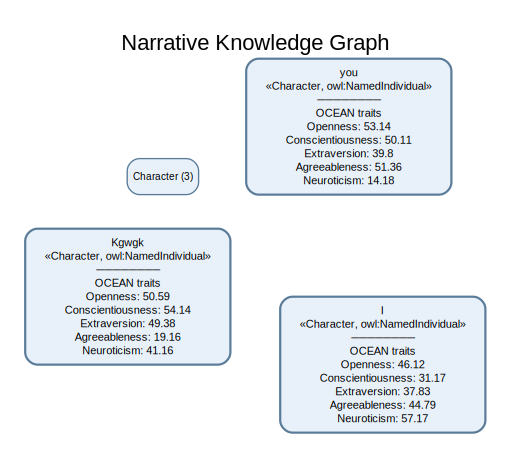

In [45]:
from IPython.display import SVG, display

display(SVG(filename=rendered_kg_path))